# Multi-objective BO: Fit of transient photoluminescence (TrPL) and transient microwave conductivity (trMC) with rate equations

This example demonstrates how to fit transient photoluminescence (TrPL) and transient microwave conductivity (trMC) data simultaneously using a multi-objective optimization approach. The model is based on the rate equations for charge carrier dynamics in semiconductors, which include trapping and detraping processes.
The model is described by the following set of differential equations:

$$\frac{dn}{dt}  = G - k_{trap} n (Bulk_{tr} - n_t) - k_{direct} n (p + p_0)$$
$$\frac{dn_t}{dt}= k_{trap} n (Bulk_{tr} - n_t) - k_{detrap} n_t (p + p_0)$$
$$\frac{dp}{dt} = G - k_{detrap} n_t (p + p_0) - k_{direct} n (p + p_0)$$

where $n$ and $p$ are the electron and hole charge carrier densities, $G$ is the generation rate in m&#8315;&#179; s&#8315;&#185;, k<sub>trap</sub> and k<sub>detrap</sub> are the trapping and detraping rates in m&#179; s&#8315;&#185;, and k<sub>direct</sub> is the bimolecular/band-to-bad recombination rate in m&#179; s&#8315;&#185;.
The TrPL signal is given by:
$$ TrPL = I_{PL} k_{direct} n (p + p_0)$$
where $I_{PL}$ is a scaling factor for the PL signal.  
The TrMC signal is given by:
$$ TrMC = I_{MC} * (r_{\mu}*n + p) $$
where $r_{\mu}$ is the mobility ratio and $I_{MC}$ is a scaling factor for the TrMC signal.

The data fitted in this notebook is taken from the following publication:
[C. Kupfer et al., Journal of Material Chemistry C, 2024, 12, 95-102](https://doi.org/10.1039/D3TC03867J)

In [6]:
# Import necessary libraries
import warnings, os, sys
# remove warnings from the output
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=RuntimeWarning)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

try:
    from optimpv import *
    from optimpv.optimizers.pymooOpti.pymooOptimizer import PymooOptimizer
    from optimpv.models.RateEqfits.RateEqAgent import RateEqAgent
    from optimpv.models.RateEqfits.RateEqModel import *
    from optimpv.models.RateEqfits.Pumps import *
except Exception as e:
    sys.path.append('../..') # add the path to the optimpv module
    from optimpv import *
    from optimpv.optimizers.pymooOpti.pymooOptimizer import PymooOptimizer
    from optimpv.models.RateEqfits.RateEqAgent import RateEqAgent
    from optimpv.models.RateEqfits.RateEqModel import *
    from optimpv.models.RateEqfits.Pumps import *


## Define the parameters for the simulation

In [7]:
params = []

k_direct = FitParam(name = 'k_direct', value = 3.9e-17, bounds = [1e-18,1e-16], log_scale = True, rescale = True, value_type = 'float', type='range', display_name=r'$k_{\text{direct}}$', unit='m$^{3}$ s$^{-1}$', axis_type = 'log',force_log=True)
params.append(k_direct)

k_trap = FitParam(name = 'k_trap', value = 4e-18, bounds = [1e-19,1e-17], log_scale = True, rescale = True, value_type = 'float', type='range', display_name=r'$k_{\text{trap}}$', unit='m$^{3}$ s$^{-1}$', axis_type = 'log',force_log=True)
params.append(k_trap)

k_detrap = FitParam(name = 'k_detrap', value = 3.1e-18, bounds = [1e-19,1e-17], log_scale = True, rescale = True, value_type = 'float', type='range', display_name=r'$k_{\text{detrap}}$', unit='s$^{-1}$', axis_type = 'log',force_log=True)
params.append(k_detrap)

N_t_bulk = FitParam(name = 'N_t_bulk', value = 1.6e23, bounds = [1e22,5e23], log_scale = True, rescale = True, value_type = 'float', type='range', display_name=r'$N_{\text{t,bulk}}$', unit='m$^{-3}$', axis_type = 'log',force_log=True)
params.append(N_t_bulk)

I_factor_PL = FitParam(name = 'I_factor_PL', value = 1e-32, bounds = [1e-33,1e-31], log_scale = True, rescale = True, value_type = 'float', type='range', display_name=r'$I_{\text{PL}}$', unit='-', axis_type = 'log', force_log=True)
params.append(I_factor_PL)

I_factor_MC = FitParam(name = 'I_factor_MC', value = 2.2e-26, bounds = [1e-27,1e-25], log_scale = True, rescale = True, value_type = 'float', type='range', display_name=r'$I_{\text{PL}}$', unit='-', axis_type = 'log', force_log=True)
params.append(I_factor_MC)

ratio_mu = FitParam(name = 'ratio_mu', value = 4.2, bounds = [1,10], log_scale = True, rescale = True, value_type = 'float', type='range', display_name=r'$\mu_{\text{ratio}}$', unit='-', axis_type = 'linear', force_log=False)
params.append(ratio_mu)


## Load and prepare the experimental data

In [8]:
# Define the path to the data 
curr_dir = os.getcwd()
parent_dir = os.path.abspath('../..') # path to the parent directory if not in Notebooks use os.getcwd()
path2data  = os.path.join(parent_dir,'Data','perovskite_trPL_trMC')
filenames = ['S25D1_L532_F0.csv','S25D1_L532_F1.csv','S25D1_L532_F2.csv'] # list of filenames to be analyzed
res_dir = os.path.join(parent_dir,'temp') # path to the results directory

# Select Gfracs used for the data
Gfracs = [1, 0.552, 0.290, 0.136, 0.087]


In [9]:
# Create a class that contains to do some basic data processing on the data
class Experiment:
    """ A set of measurements """
    def __init__(self, path2data, filenames, Gfracs, laserCenter=0, num_pts=1e3, take_log=False):
        self.path2data = path2data
        self.filenames = filenames
        self.Gfracs = Gfracs
        self.laserCenter = laserCenter
        self.num_pts = num_pts
        self.take_log = take_log
        
        self.get_data()
        pass
    
    
    def get_data(self):
        self.X_raw, self.y_raw_MW, self.y_raw_PL = [],[],[]
        for filename in self.filenames:
            # Create empty lists to store data
            X,y_MW, y_PL = [],[],[]
            
            #Load file and extract data
            with open(os.path.join(self.path2data, filename)) as f:
                for line in f:
                    tmp=line.strip("\n").split(",")
                    X.append(float(tmp[3]))
                    y_MW.append(float(tmp[4]))
                    
                    if len(tmp)>8:
                        y_PL.append(float(tmp[10]))
                    else:
                        raise ValueError("The file does not contain PL data")
            
            # Create output arrays
            self.X_raw.append(np.array(X))
            self.y_raw_MW.append(np.array(y_MW))
            self.y_raw_PL.append(np.array(y_PL))
        pass
    
    
    def process_data(self, cut_rise=False, cut_time=None, cut_sigma=False):
        # Create empty lists to store data
        X_out, y_out_MW, y_out_PL = [],[],[]
        self.X_processed, self.y_processed_MW, self.y_processed_PL = [],[],[]
        self.signalParams={}
        self.background_out_PL=[]
        # Data processing:
        for X, y_MW, y_PL, Gfrac in zip(self.X_raw, self.y_raw_MW, self.y_raw_PL, self.Gfracs):
                
            # Subtract the background from MW and PL data
            index = np.where(X<(-10e-9))  # Calculate the background from the average of the signal up to 10ns before the peak (this buffer is to prevent the rise of the peak to affect the background)
            self.signalParams["MW_background"] = np.mean(y_MW[index])
            self.signalParams["PL_background"] = np.mean(y_PL[index])
            self.signalParams["MW_sigma"] = np.std(y_MW[index])
            self.signalParams["PL_sigma"] = np.std(y_PL[index])
            
            
            y_MW = y_MW - self.signalParams["MW_background"]
            y_PL = y_PL - self.signalParams["PL_background"]
            print('PL Sigma {}, PL background {}, MW Sigma {}, MW background {}'.format(self.signalParams["PL_sigma"],self.signalParams["PL_background"],self.signalParams["MW_sigma"],self.signalParams["MW_background"]))
            
            # Find the peak position
            self.signalParams["index_max_MW"] = np.argmax(abs(y_MW))
            self.signalParams["index_max_PL"] = np.argmax(abs(y_PL))
            
            # Find the sign of the peak
            self.signalParams["sign_max_MW"] = np.sign(y_MW[self.signalParams["index_max_MW"]])
            self.signalParams["sign_max_PL"] = np.sign(y_PL[self.signalParams["index_max_PL"]])
            
            # Remove datapoints at the beginning of the signal
            if cut_rise == "MW":
                index = np.where(X >= X[self.signalParams["index_max_MW"]])
            elif cut_rise == "PL":
                index = np.where(X >= X[self.signalParams["index_max_PL"]])
            elif cut_rise == "Time":
                index = np.where(X > cut_time)
            else:
                index = np.where(X > self.laserCenter)
                
            X = X[index]
            # Remove datapoints before the laser peak from the MW and PL signal and make sure, that the peak is positive
            y_MW = y_MW[index]*self.signalParams["sign_max_MW"]
            y_PL = y_PL[index]*self.signalParams["sign_max_PL"]
            
            # Remove datapoints that aren't significant enough (in either measurement)
            if cut_sigma:
                sigma = float(cut_sigma)
                index = np.where((np.abs(y_MW)>sigma*self.signalParams["MW_sigma"]) & (np.abs(y_PL)>sigma*self.signalParams["PL_sigma"]))

                X = X[index]
                y_MW = y_MW[index]
                y_PL = y_PL[index]
            
            
            # Interpolate to get num_pts
            X_interp = np.geomspace(X[1],X[-1],int(self.num_pts))

            # Add 0 to the beginning of X_interp
            X_interp = np.insert(X_interp,0,0)
            y_interp_MW = np.interp(X_interp,X,y_MW)
            y_interp_PL = np.interp(X_interp,X,y_PL)

            # Take the log of the data
            if self.take_log:
                y_interp_MW = np.log10(y_interp_MW)
                y_interp_PL = np.log10(y_interp_PL)
                
                # Remove all data points where either signal is NaN
                mask_NaNs = np.logical_or(np.isnan(y_interp_PL), np.isnan(y_interp_MW))
                X_interp = X_interp[~mask_NaNs]
                y_interp_MW = y_interp_MW[~mask_NaNs]
                y_interp_PL = y_interp_PL[~mask_NaNs]
                print('Removed {} Data Points while taking the logarithm!'.format(np.count_nonzero(mask_NaNs)))
            
            # Append the data to the output
            for i in range(len(X_interp)):
                X_out.append([X_interp[i],Gfrac])
                y_out_MW.append(y_interp_MW[i])
                y_out_PL.append(y_interp_PL[i])
                self.background_out_PL.append(self.signalParams["PL_sigma"]*np.sqrt(2/np.pi))
                
            self.X_processed.append(np.array(X_interp))
            self.y_processed_MW.append(np.array(y_interp_MW))
            self.y_processed_PL.append(np.array(y_interp_PL))

        # Convert the output to arrays
        self.X = np.array(X_out)
        self.y_MW = np.array(y_out_MW)
        self.y_PL = np.array(y_out_PL)
        pass


In [10]:
# Load the data and process it
data_exp = Experiment(path2data, filenames, Gfracs, laserCenter=2.8E-8, take_log=False)
data_exp.process_data(cut_rise=False, cut_time=None ,cut_sigma=0)
X = data_exp.X
y_MW = data_exp.y_MW
y_PL = data_exp.y_PL
back_PL = data_exp.background_out_PL

# remove all point where PL is below 0
mask = np.where(y_PL<0)
y_PL = np.delete(y_PL,mask)
X = np.delete(X,mask,axis=0)
y_MW = np.delete(y_MW,mask)
back_PL = np.delete(back_PL,mask)
# remove all point where MW is below 0
mask = np.where(y_MW<0)
y_MW = np.delete(y_MW,mask)
X = np.delete(X,mask,axis=0)
y_PL = np.delete(y_PL,mask)
back_PL = np.delete(back_PL,mask)
from sklearn.preprocessing import minmax_scale
# Assign weights based on the signal strength
weight_PL = None #1/(np.abs(y_PL))
weight_MW = None #1/(np.abs(y_MW))
# weight_MW = minmax_scale(weight_MW, feature_range=(1,1000))


PL Sigma 2.9602988876119335e-05, PL background -0.003598912016122306, MW Sigma 3.780285415804477e-05, MW background -0.0007008701257225716
PL Sigma 3.0399603508164594e-05, PL background -0.003610847480546366, MW Sigma 4.040993545427417e-05, MW background -0.0008486578742130771
PL Sigma 2.5489343983201138e-05, PL background -0.0031102876606446113, MW Sigma 3.75774071903544e-05, MW background -0.0009373141997225259


{'RateEq_trPL_mse_soft_l1': 0.06916844589940263, 'RateEq_trMC_mse_soft_l1': 0.0019317690776468055}


Text(0, 0.5, 'MW (a.u.)')

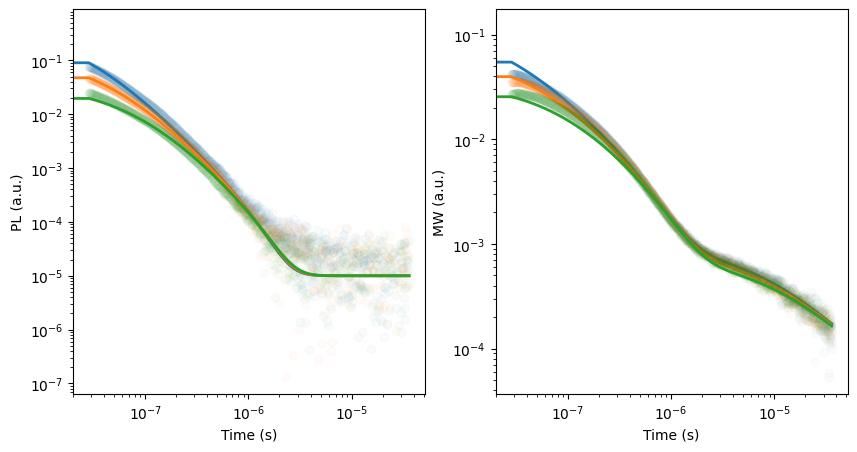

In [11]:
# RateEqModel parameters
fpu = 1e3 # Frequency of the pump laser in Hz
N0 = 1.041e24 # Initial carrier density in m-3
background = 0 # Background illumination 
Gfracs = [1, 0.552, 0.290] # Gfracs used for the data

# Define the Agent and the target metric/loss function
metric = 'mse'
loss = 'soft_l1'
pump_args = {'N0': N0, 'fpu': fpu , 'background' : background, }

# 50 log spaced points data X, y_PL, y_MW
# t_min except 0
num_pts = 20
t_min = X[X[:,0]>0,0].min()
X_log = np.geomspace(t_min,X[:,0].max(),num_pts)
X_log = np.insert(X_log,0,0)
# get teh closest 50 points to the log spaced points
X_50 = np.zeros((int(len(X_log)*len(Gfracs)),2))
y_PL_50 = np.zeros(int(len(X_log)*len(Gfracs)))
y_MW_50 = np.zeros(int(len(X_log)*len(Gfracs)))

idx_main = 0
for g in Gfracs:
    idx = 0
    for i in range(len(X_log)):
        index = np.argmin(abs(X[X[:,1]==g,0]-X_log[idx]))
        X_50[idx_main] = X[X[:,1]==g][index]
        y_PL_50[idx_main] = y_PL[X[:,1]==g][index]
        y_MW_50[idx_main] = y_MW[X[:,1]==g][index]
        idx += 1
        idx_main += 1
        
RateEq = RateEqAgent(params, [X,X], [y_PL,y_MW], model = BTD_model, pump_model = initial_carrier_density, pump_args = pump_args, fixed_model_args = {}, metric = [metric,metric], loss = [loss,loss], threshold=[0.5,0.5],minimize=[True,True],exp_format=['trPL','trMC'],detection_limit=1e-5, weight=[weight_PL,weight_MW], transforms ='log')

# Not necessary, but here we run the simulation with the parameters to test the model
# Run the simulation with the parameters
y_PL_fit = RateEq.run(parameters={},exp_format='trPL')
y_MC_fit = RateEq.run(parameters={},exp_format='trMC')
print(RateEq.run_Ax(parameters={})) 

# Make a plot with 2 subplots for PL and MW
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(10,5))

for i in range(len(data_exp.X_processed)):
    ax1.semilogx(data_exp.X_processed[i], data_exp.y_processed_PL[i], 'o', label=data_exp.Gfracs[i],color='C'+str(i),alpha=0.025)
    ax1.plot(X[X[:,1]==Gfracs[i],0], y_PL_fit[X[:,1]==Gfracs[i]],'-',label=str(Gfracs[i]), color = 'C'+str(i), linewidth=2)
    ax2.semilogx(data_exp.X_processed[i], data_exp.y_processed_MW[i], 'o', label=data_exp.Gfracs[i],color='C'+str(i),alpha=0.025)
    ax2.plot(X[X[:,1]==Gfracs[i],0], y_MC_fit[X[:,1]==Gfracs[i]],'-',label=str(Gfracs[i]), color = 'C'+str(i), linewidth=2)
    # ax1.plot(X_50[X_50[:,1]==Gfracs[i],0], y_PL_50[X_50[:,1]==Gfracs[i]],'o',label=str(Gfracs[i]), color = 'r')
    # ax2.plot(X_50[X_50[:,1]==Gfracs[i],0], y_MW_50[X_50[:,1]==Gfracs[i]],'o',label=str(Gfracs[i]), color = 'r')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('PL (a.u.)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('MW (a.u.)')

## Run the optimization

In [12]:
# Define the optimizer
optimizer = PymooOptimizer(params=params, agents=RateEq, algorithm='NSGA2', pop_size=20, n_gen=100, name='pymoo_multi_obj', verbose_logging=True,max_parallelism=20, )

In [13]:
res = optimizer.optimize() # run the optimization with ax

[INFO 04-14 11:46:30] optimpv.pymooOptimizer: Starting optimization using NSGA2 algorithm
[INFO 04-14 11:46:30] optimpv.pymooOptimizer: Population size: 20, Generations: 100
[INFO 04-14 11:46:30] optimpv.pymooOptimizer: Generation 1: Best objective = 0.050284


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      2 |             - |             -


[INFO 04-14 11:46:31] optimpv.pymooOptimizer: Generation 2: Best objective = 0.034783


     2 |       40 |      2 |  0.8674634227 |         ideal


[INFO 04-14 11:46:31] optimpv.pymooOptimizer: Generation 3: Best objective = 0.034783


...

    98 |     1960 |     20 |  0.1415988204 |         nadir


[INFO 04-14 11:47:16] optimpv.pymooOptimizer: Generation 99: Best objective = 0.002673


    99 |     1980 |     20 |  0.0000857807 |             f


[INFO 04-14 11:47:16] optimpv.pymooOptimizer: Generation 100: Best objective = 0.002673
[INFO 04-14 11:47:16] optimpv.pymooOptimizer: Optimization completed after 101 generations
[INFO 04-14 11:47:16] optimpv.pymooOptimizer: Number of function evaluations: 2000
[INFO 04-14 11:47:16] optimpv.pymooOptimizer: Final population size: 20
[INFO 04-14 11:47:16] optimpv.pymooOptimizer: Pareto front size: 20


   100 |     2000 |     20 |  0.0005378946 |             f


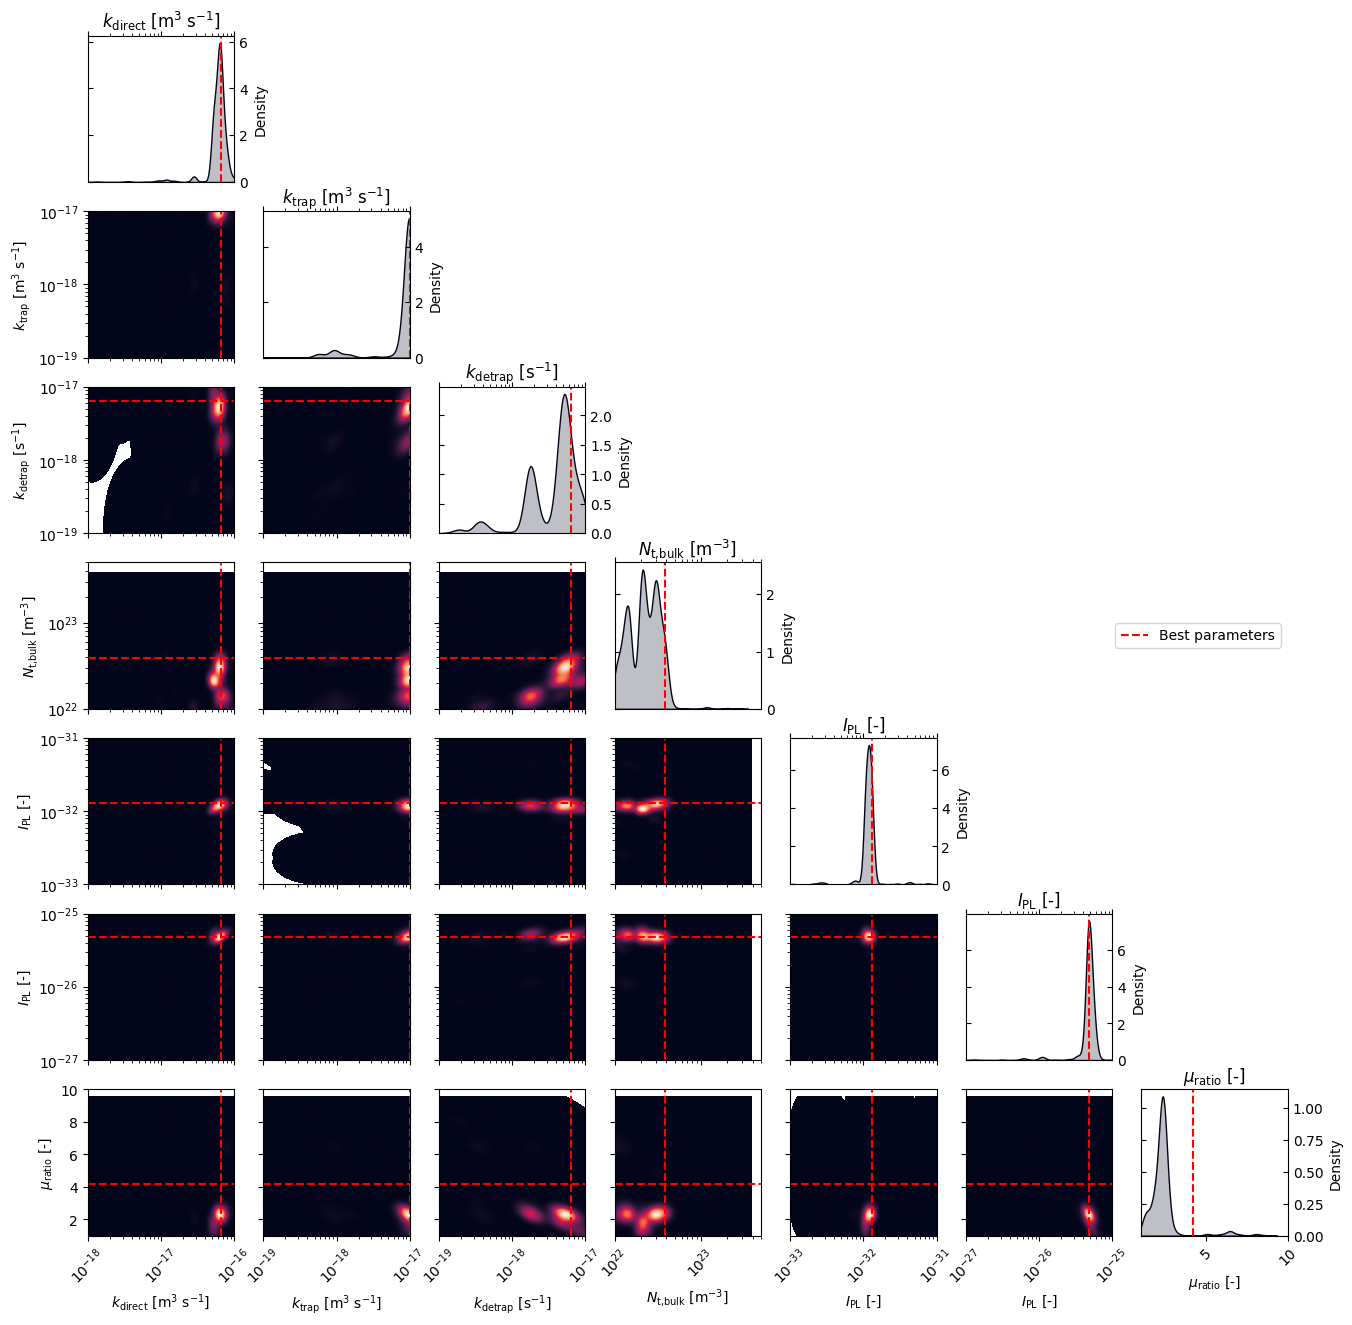

In [14]:
# Plot the density of the exploration of the parameters
# this gives a nice visualization of where the optimizer focused its exploration and may show some correlation between the parameters
plot_dens = True
if plot_dens:
    from optimpv.posterior.exploration_density import *
    best_parameters = {}
    for p in optimizer.params:
        best_parameters[p.name] = p.value

    fig_dens, ax_dens = plot_density_exploration(params, optimizer = optimizer, best_parameters = best_parameters, optimizer_type = 'pymoo')

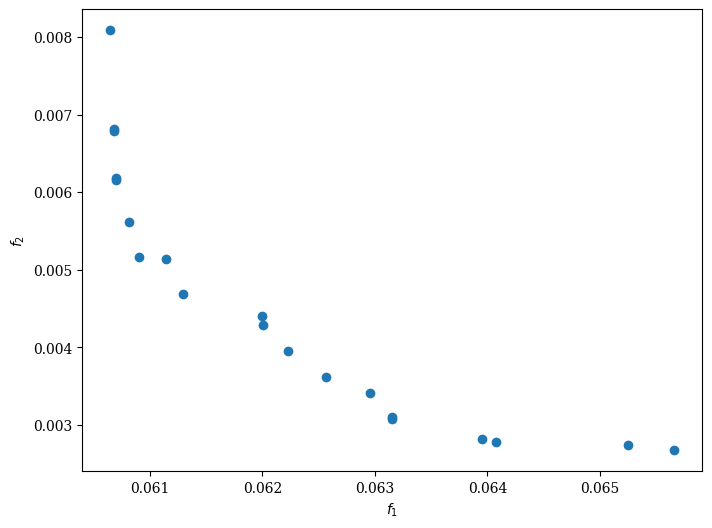

In [15]:
from pymoo.visualization.scatter import Scatter

Scatter().add(res.F, label="Pareto Front").show()


In [16]:
# get the best parameters and update the params list in the optimizer and the agent
optimizer.update_params_with_best_balance() # update the params list in the optimizer with the best parameters
RateEq.params = optimizer.params # update the params list in the agent with the best parameters

# print the best parameters
print('Best parameters:')
for p in optimizer.params:
    print(p.name, 'fitted value:', p.value)
    

Best parameters:
k_direct fitted value: 5.227069119128607e-17
k_trap fitted value: 9.972981934224475e-18
k_detrap fitted value: 4.5880975210268385e-18
N_t_bulk fitted value: 2.2130502620306796e+22
I_factor_PL fitted value: 1.071674380071781e-32
I_factor_MC fitted value: 4.66332121728611e-26
ratio_mu fitted value: 1.8092718649376622


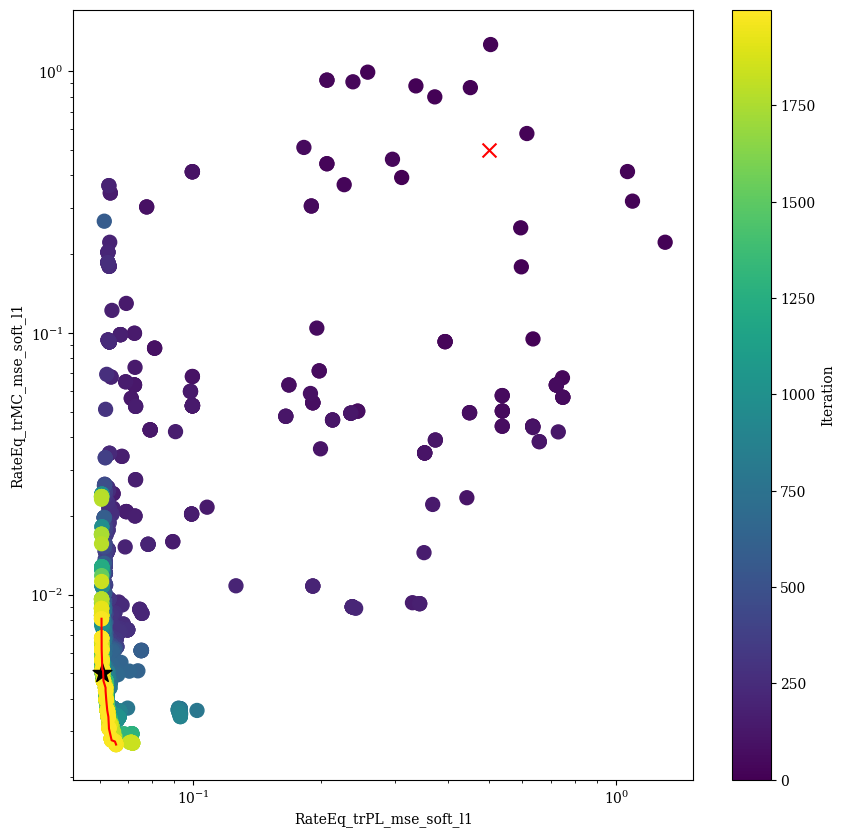

In [17]:
import matplotlib
# import itertools
from itertools import combinations
comb = list(combinations(optimizer.all_metrics, 2))
threshold_list = []
for i in range(len(optimizer.agents)):
    for j in range(len(optimizer.agents[i].threshold)):
        threshold_list.append(optimizer.agents[i].threshold[j])
threshold_comb = list(combinations(threshold_list, 2))
pareto = np.asarray(res.F)

cm = matplotlib.colormaps.get_cmap('viridis')
df = optimizer.get_df_from_pymoo() # get the dataframe from the optimizer
# create pareto df
dum_dic = {}

for i , metr in enumerate(optimizer.all_metrics):
    if i not in df.keys():
        dum_dic[metr] = pareto[:, i]

df_pareto = pd.DataFrame(dum_dic)
dum_dic = RateEq.run_Ax(parameters={})
best_balanced = [ dum_dic[metr] for metr in optimizer.all_metrics]

for c,t_c in zip(comb,threshold_comb):
    plt.figure(figsize=(10, 10))
    plt.scatter(df[c[0]],df[c[1]],c=df.index, cmap=cm, marker='o', s=100) # plot the points with color according to the iteration
    cbar = plt.colorbar()
    cbar.set_label('Iteration')
    sorted_df = df_pareto.sort_values(by=c[0])
    plt.plot(sorted_df[c[0]],sorted_df[c[1]],'r') 
    plt.scatter(t_c[0],t_c[1],c='r', marker='x', s=100) # plot the threshold
    plt.scatter(best_balanced[0],best_balanced[1],c='k', marker='*', s=200, label='Best balanced') # plot the best balanced point
    plt.xlabel(c[0])
    plt.ylabel(c[1])
    plt.xscale('log')
    plt.yscale('log')
    
    
    plt.show()

{'RateEq_trPL_mse_soft_l1': 0.06096075573909543, 'RateEq_trMC_mse_soft_l1': 0.0050025145206102906}


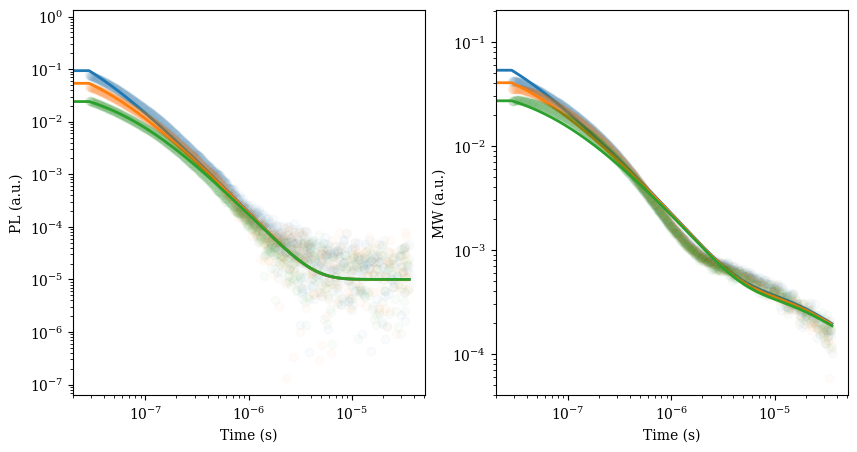

In [18]:
# Run the simulation with the parameters
y_PL_fit = RateEq.run(parameters={},exp_format='trPL')
y_MC_fit = RateEq.run(parameters={},exp_format='trMC')
print(RateEq.run_Ax(parameters={}))
# Make a plot with 2 subplots for PL and MW
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(10,5))

for i in range(len(Gfracs)):
    ax1.semilogx(X[X[:,1]==Gfracs[i],0], y_PL[X[:,1]==Gfracs[i]], 'o', color='C'+str(i),alpha=0.025)
    ax1.plot(X[X[:,1]==Gfracs[i],0], y_PL_fit[X[:,1]==Gfracs[i]],'-', color = 'C'+str(i), linewidth=2)
    ax2.semilogx(X[X[:,1]==Gfracs[i],0], y_MW[X[:,1]==Gfracs[i]], 'o', color='C'+str(i),alpha=0.025)
    ax2.plot(X[X[:,1]==Gfracs[i],0], y_MC_fit[X[:,1]==Gfracs[i]],'-', color = 'C'+str(i), linewidth=2)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('PL (a.u.)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('MW (a.u.)')
plt.show()
